In [69]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import time
import threading
import sys
import seaborn as sns
"Ok"

'Ok'

In [70]:
SEED = 42  # Случайное начальное число
PROBABILITY = 0.1  # Вероятность появления ребра
N_RANGE = range(5, 1001, 3)  # Количество вершин
DRAW_AND_QUIT = -1  # Преждевременная остановка с визуализацией графа (-1 - откл.)
RETESTS = 30  # Количество испытаний для каждого числа вершин
MAX_RUNTIME = 120
STOP_NOW = False

times_mean = []  # среднее время выполнения
times_std = []  # среднее квадратичное отклонение по времени выполнения
selected_times, selected_i = None, None

times = np.array([None] * RETESTS)  # Массив фактического времени выполнения длины RETESTS
pointer = 0  # Указатель на индекс массива times

In [71]:
# Декоратор, измеряющий время исполнения алгоритма
def measure_execution_time(func):
    def wrapper(*args, **kwargs):
        global times, pointer

        start_time = time.perf_counter()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()
        execution_time = end_time - start_time
        times[pointer] = execution_time
        pointer = (pointer + 1) % RETESTS

        return result

    return wrapper

In [72]:
class ConnectivityList:
    def __init__(self, graph: nx.Graph):
        """Объект хранит список связности и количество вершин графа (см. Идея 2 Список связности)"""
        self.conlist = []
        self.length = graph.number_of_nodes()
        # Для каждой вершины будем хранить маску связности в списке связности по индексу с номером этой вершины
        for node in range(self.length):
            self.conlist.append(self.to_binary(graph.neighbors(node)))

    @staticmethod
    def to_binary(neighbors) -> int:
        """Метод создает на основе итератора битовую маску, где каждый бит хранит связь текущей вершины с i-м соседом"""
        binary = 0

        # Создаем маску связности
        for i in neighbors:
            binary |= 1 << i
        return binary

    def __str__(self) -> str:
        """Метод создает текстовое представление списка связности"""
        res_str = ""
        for node, mask in enumerate(self.conlist):
            res_str += f"{node}: {bin(mask)}\n"

        return res_str

    def check_independence(self, subset: int) -> bool:
        """Метод проверяет независимость элементов подмножества с помощью маски соседей (см. Идея 1 Битовая маска)"""
        neighbors_mask = 0
        temp = subset
        index = 0
        while temp:
            if temp & 1:
                neighbors_mask |= self.conlist[index]
            temp >>= 1
            index += 1

        if not neighbors_mask & subset:
            return True

        return False

In [73]:
@measure_execution_time
def algorithm(graph: nx.Graph) -> int:
    global STOP_NOW

    cl = ConnectivityList(graph)
    misl = 1  # max independent set length (искомое значение)

    independent_subsets = [0, 1]
    step = 1
    while step < cl.length:
        l = len(independent_subsets)
        for i in range(l):
            if STOP_NOW:
                output()
            # Добавляем к подмножеству новую вершину
            new_subset = independent_subsets[i] | (1 << step)

            # Проверка на независимость
            if cl.check_independence(new_subset):
                nodes_count = new_subset.bit_count()
                if nodes_count > misl:
                    misl = nodes_count

                # Добавляем только "перспективные" подмножества
                if nodes_count + cl.length - step - 1 > misl:
                    independent_subsets.append(new_subset)
        step += 1

    return misl

In [74]:
def stop():
    global STOP_NOW
    STOP_NOW = True

def main():
    global times_mean, times_std, times, selected_times, selected_i

    timer = threading.Timer(MAX_RUNTIME * 60, stop)
    timer.start()

    i = 0

    for n in N_RANGE:
        graph = nx.erdos_renyi_graph(n, p=PROBABILITY, seed=SEED)

        # Объявляем новый порядок вершин по возрастанию степеней
        node_order = [node for node, _ in sorted(dict(graph.degree()).items(), key=lambda x: x[1])]
        # Сопоставляем каждой вершине её новое название
        mapping = {old: new for new, old in enumerate(node_order)}
        # переименовываем вершены, сохраняем полученную копию в новую переменную
        sorted_graph = nx.relabel_nodes(graph, mapping)

        for _ in range(RETESTS):
            result = algorithm(sorted_graph)

            if DRAW_AND_QUIT != -1 and n >= DRAW_AND_QUIT:
                print(result)
                pos = nx.spring_layout(sorted_graph)
                nx.draw(sorted_graph, pos, with_labels=True, node_color='lightblue', node_size=500)
                plt.show()
                timer.cancel()
                sys.exit(0)
        
        selected_times, selected_i = times, i
        times_mean.append(times.mean())
        times_std.append(times.std())

        i += 1

    timer.cancel()
    output()

def output():
    global times_mean, times_std, N_RANGE

    print(times_mean)
    print(times_std)

    plt.plot(list(N_RANGE[:len(times_mean)]), times_mean)
    plt.show()

    sys.exit(0)

[np.float64(1.7676666629995452e-05), np.float64(6.817333320820277e-05), np.float64(0.0003637933333266119), np.float64(0.0028002366666138793), np.float64(0.011899386666603581), np.float64(0.059811026666739056), np.float64(0.3524747199999789), np.float64(0.748057556666572), np.float64(4.06394174666669), np.float64(11.442686546666664), np.float64(37.389310603333435), np.float64(170.1976778566667)]
[np.float64(4.413440318090975e-06), np.float64(7.740066009020443e-06), np.float64(2.347755479173877e-06), np.float64(9.07389900634989e-05), np.float64(0.00021131607721189716), np.float64(0.001198581263224694), np.float64(0.0046421379245458645), np.float64(0.002789437533954452), np.float64(0.03252991539847136), np.float64(0.12716213006447805), np.float64(0.22731166389487673), np.float64(0.7358686455419161)]


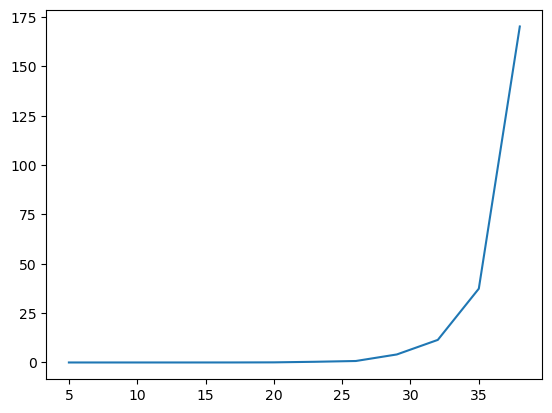

SystemExit: 0

In [75]:
main()

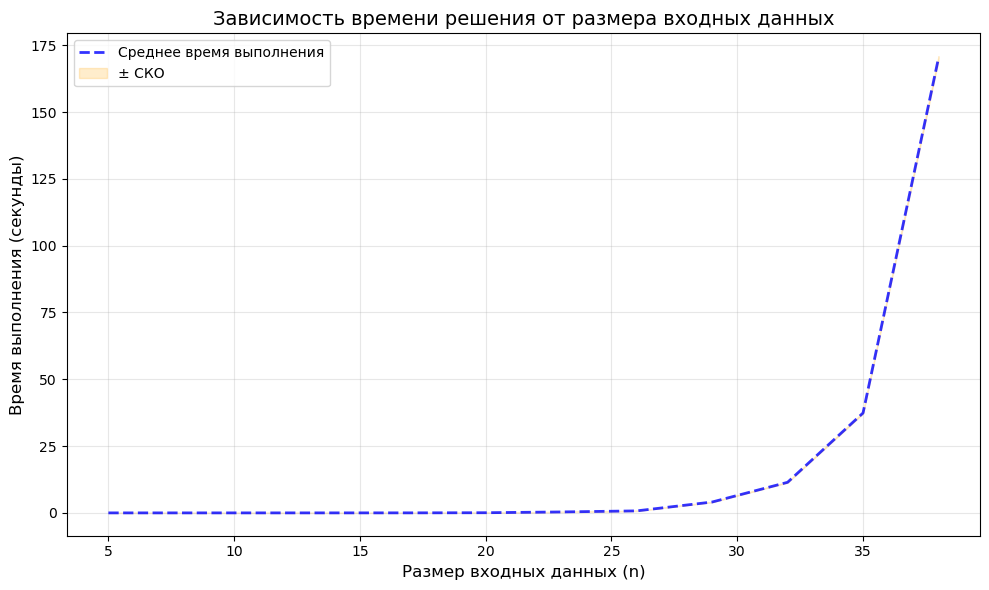

In [76]:
plt.figure(figsize=(10, 6))

n_np = np.array(list(N_RANGE[:len(times_mean)]))
times_mean_np = np.array(times_mean)
times_std_np = np.array(times_std)

plt.plot(n_np, times_mean_np, 'b--', linewidth=2, alpha=0.8, label='Среднее время выполнения')

plt.fill_between(n_np,
                 times_mean_np - times_std_np,
                 times_mean_np + times_std_np,
                 color='orange', alpha=0.2, label='± СКО')

plt.xlabel('Размер входных данных (n)', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('Зависимость времени решения от размера входных данных', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

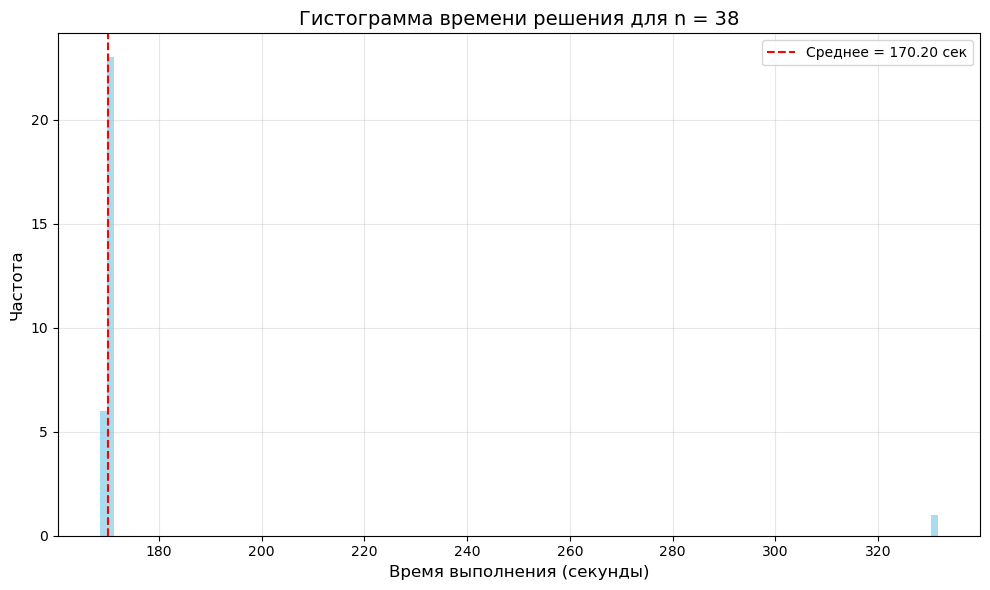

In [78]:
plt.figure(figsize=(10, 6))
plt.hist(selected_times, bins=120, color='skyblue', alpha=0.7)
plt.axvline(times_mean_np[selected_i], color='red', linestyle='--', linewidth=1.5,
           label=f'Среднее = {times_mean_np[selected_i]:.2f} сек')
plt.xlabel('Время выполнения (секунды)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title(f'Гистограмма времени решения для n = {n_np[selected_i]}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()